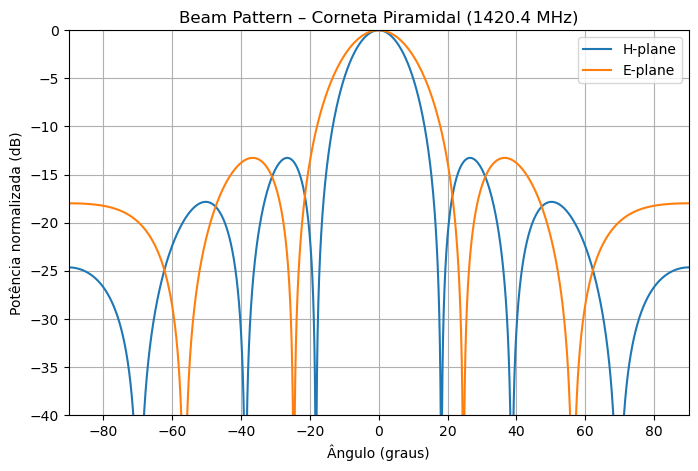

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parâmetros físicos
# -------------------------
c = 3e8
f = 1420.4e6
lam = c / f
k = 2 * np.pi / lam

a1 = 0.676  # abertura H (m)
b1 = 0.507  # abertura E (m)

# Ângulo
theta = np.linspace(-90, 90, 20001) * np.pi / 180

# -------------------------
# Beam pattern analítico
# -------------------------
def sinc(x):
    return np.sinc(x / np.pi)

# H-plane (variação em x)
E_H = sinc(0.5 * k * a1 * np.sin(theta))
E_H = np.abs(E_H)**2
E_H /= E_H.max()

# E-plane (variação em y)
E_E = sinc(0.5 * k * b1 * np.sin(theta))
E_E = np.abs(E_E)**2
E_E /= E_E.max()

# Converter para dB
E_H_dB = 10 * np.log10(E_H + 1e-12)
E_E_dB = 10 * np.log10(E_E + 1e-12)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(theta*180/np.pi, E_H_dB, label="H-plane")
plt.plot(theta*180/np.pi, E_E_dB, label="E-plane")
plt.ylim(-40, 0)
plt.xlim(-90, 90)
plt.xlabel("Ângulo (graus)")
plt.ylabel("Potência normalizada (dB)")
plt.title("Beam Pattern – Corneta Piramidal (1420.4 MHz)")
plt.grid(True)
plt.legend()
plt.show()


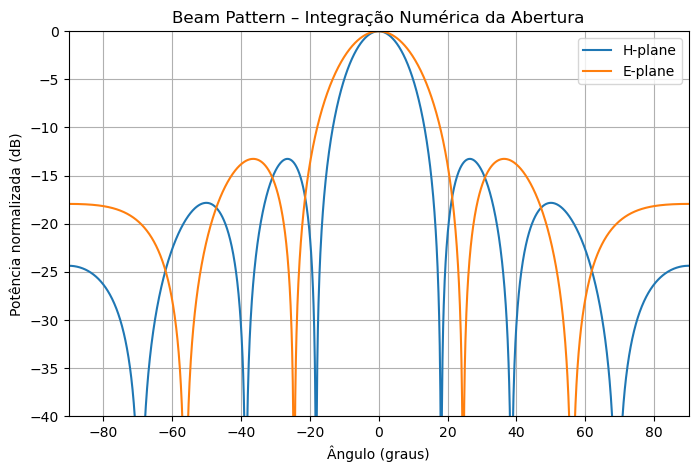

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Constantes físicas
# ------------------------------------------------
c = 3e8
f = 1420.4e6
lam = c / f
k = 2 * np.pi / lam

# ------------------------------------------------
# Geometria da abertura (metros)
# ------------------------------------------------
a1 = 0.676  # H-plane (x)
b1 = 0.507  # E-plane (y)

# ------------------------------------------------
# Malha da abertura
# ------------------------------------------------
Nx = 400
Ny = 300

x = np.linspace(-a1 / 2, a1 / 2, Nx)
y = np.linspace(-b1 / 2, b1 / 2, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y)

# Campo na abertura (uniforme)
E_ap = np.ones_like(X)

# ------------------------------------------------
# Ângulos de observação
# ------------------------------------------------
theta = np.linspace(-90, 90, 2001) * np.pi / 180


# ------------------------------------------------
# Integração numérica
# ------------------------------------------------
def far_field(theta_x, theta_y):
    phase = np.exp(-1j * k * (X * np.sin(theta_x) + Y * np.sin(theta_y)))
    return np.sum(E_ap * phase) * dx * dy


# H-plane (y = 0)
E_H = np.array([far_field(th, 0.0) for th in theta])
P_H = np.abs(E_H) ** 2
P_H /= P_H.max()

# E-plane (x = 0)
E_E = np.array([far_field(0.0, th) for th in theta])
P_E = np.abs(E_E) ** 2
P_E /= P_E.max()

# Converter para dB
P_H_dB = 10 * np.log10(P_H + 1e-14)
P_E_dB = 10 * np.log10(P_E + 1e-14)

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(theta * 180 / np.pi, P_H_dB, label="H-plane")
plt.plot(theta * 180 / np.pi, P_E_dB, label="E-plane")
plt.xlim(-90, 90)
plt.ylim(-40, 0)
plt.xlabel("Ângulo (graus)")
plt.ylabel("Potência normalizada (dB)")
plt.title("Beam Pattern – Integração Numérica da Abertura")
plt.grid(True)
plt.legend()
plt.show()
